# Notebook 03 — Evaluate 3 Trained Multiphase PPO Agents on Original Workload

Notebook này dùng để đánh giá bổ sung 3 agent PPO đã train ở Notebook 02 trên workload multiphase.

Mục tiêu:
- Không train lại PPO.
- Load 3 model PPO đã train sẵn: seed42, seed66, seed123.
- Evaluate từng agent trên `workload_real_original.csv`.
- So sánh 3 seed để chọn representative seed có trade-off tốt nhất.
- So sánh PPO với baseline: RoundRobin, Threshold, BestFit, Fixed-Keep.
- Xuất CSV và hình để đưa vào báo cáo.

**Lưu ý quan trọng:** Notebook này là evaluation/inference only. Không có `model.learn(...)`.

In [46]:
from pathlib import Path
import sys
import os
import json
import math
import warnings
from dataclasses import asdict, fields, replace, is_dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Notebook 03: Evaluate 3 trained multiphase PPO agents on original workload")

Notebook 03: Evaluate 3 trained multiphase PPO agents on original workload


In [47]:
def find_project_root(start: Path = None) -> Path:
    """
    Tìm project root bằng cách đi ngược lên tới khi thấy src/ và notebooks/.
    Notebook nên được đặt trong thư mục notebooks/.
    """
    if start is None:
        start = Path.cwd()
    start = start.resolve()

    for p in [start] + list(start.parents):
        if (p / "src").exists() and (p / "notebooks").exists():
            return p

    for p in [start] + list(start.parents):
        if (p / "src").exists() and (p / "data").exists():
            return p

    raise RuntimeError(
        "Không tìm thấy project root. Hãy đặt notebook này trong thư mục notebooks/ "
        "của project NT549.Q21-DRL-ERM-CLOUD rồi chạy lại."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("data exists:", (PROJECT_ROOT / "data").exists())
print("outputs exists:", (PROJECT_ROOT / "outputs").exists())

PROJECT_ROOT = C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD
src exists: True
data exists: True
outputs exists: True


In [48]:
try:
    from sb3_contrib import MaskablePPO
    print("Imported MaskablePPO")
except Exception as e:
    raise ImportError(
        "Thiếu sb3-contrib. Cài bằng cell sau rồi Restart Kernel:\n"
        "import sys\n"
        "!{sys.executable} -m pip install sb3-contrib stable-baselines3"
    ) from e

from src.energy_env_v8_1 import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import (
    FixedPolicy,
    RoundRobinPolicy,
    ThresholdPolicy,
    BestFitPolicy,
    run_policy,
)
from src.evaluation import trace_to_dataframe, save_trace_artifacts

print("Imported project modules successfully")

Imported MaskablePPO
Imported project modules successfully


## 1. Khai báo seed, data path, output path

Notebook này mặc định evaluate 3 seed: 42, 66, 123.

Nếu model path của bạn khác, điền vào `MANUAL_MODEL_PATHS`.  
Nếu để trống, notebook sẽ tự tìm `model_v8_1_maskableppo.zip` trong `outputs/`.

In [49]:
SEEDS = [66]
TIMESTEPS = 2_500_000

ORIGINAL_WORKLOAD_PATH = PROJECT_ROOT / "data" / "workload_real_original.csv"
VM_SNAPSHOT_PATH = PROJECT_ROOT / "data" / "vm_snapshots.csv"

# Nếu auto-find không tìm thấy model, bạn dán path thủ công ở đây.
# Ví dụ:
# MANUAL_MODEL_PATHS = {
#     42: PROJECT_ROOT / "outputs" / "v8_1" / "multiphase" / "v8_1_multiphase_seed42_2500000" / "model_v8_1_maskableppo.zip",
#     66: PROJECT_ROOT / "outputs" / "v8_1" / "multiphase" / "v8_1_multiphase_seed66_2500000" / "model_v8_1_maskableppo.zip",
#     123: PROJECT_ROOT / "outputs" / "v8_1" / "multiphase" / "v8_1_multiphase_seed123_2500000" / "model_v8_1_maskableppo.zip",
# }
MANUAL_MODEL_PATHS = {
    66: PROJECT_ROOT / "outputs" / "v8_1" / "multiphase" / "v8_1_multiphase_seed66_2500000" / "model_v8_1_maskableppo.zip"
}
OUT_DIR = PROJECT_ROOT / "outputs" / "v8_1" / "original_eval_from_trained_model" / "three_seeds"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Original workload path:", ORIGINAL_WORKLOAD_PATH)
print("VM snapshot path:", VM_SNAPSHOT_PATH)
print("Output dir:", OUT_DIR)

assert ORIGINAL_WORKLOAD_PATH.exists(), (
    f"Không tìm thấy {ORIGINAL_WORKLOAD_PATH}. "
    "Bạn cần đặt workload_real_original.csv trong thư mục data/."
)

Original workload path: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\workload_real_original.csv
VM snapshot path: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\vm_snapshots.csv
Output dir: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds


## 2. Tự tìm model đã train của 3 seed

Yêu cầu phải có model đã train từ Notebook 02, ví dụ:

```text
outputs/.../v8_1_multiphase_seed42_2500000/model_v8_1_maskableppo.zip
outputs/.../v8_1_multiphase_seed66_2500000/model_v8_1_maskableppo.zip
outputs/.../v8_1_multiphase_seed123_2500000/model_v8_1_maskableppo.zip
```

In [50]:
def find_trained_model_for_seed(project_root: Path, seed: int) -> Path:
    """
    Tự tìm model PPO đã train từ Notebook 02 theo từng seed.
    Ưu tiên file model_v8_1_maskableppo.zip có seed tương ứng trong outputs/.
    """
    if seed in MANUAL_MODEL_PATHS:
        manual = Path(MANUAL_MODEL_PATHS[seed])
        if manual.exists():
            return manual
        raise FileNotFoundError(f"MANUAL_MODEL_PATHS[{seed}] không tồn tại: {manual}")

    candidates = list((project_root / "outputs").rglob("model_v8_1_maskableppo.zip"))

    seed_text = f"seed{seed}"
    timestep_text = str(TIMESTEPS)

    ranked = []
    for p in candidates:
        s = str(p).lower()
        score = 0

        if seed_text.lower() in s:
            score += 10
        if timestep_text in s:
            score += 5
        if "multiphase" in s:
            score += 3
        if "original" not in s:
            score += 1

        ranked.append((score, p))

    ranked.sort(reverse=True, key=lambda x: x[0])

    if ranked and ranked[0][0] >= 10:
        return ranked[0][1]

    all_found = "\n".join(str(p) for p in candidates[:20])
    raise FileNotFoundError(
        f"Không tìm thấy model cho seed{seed}.\n"
        f"Hãy kiểm tra outputs/ có model_v8_1_maskableppo.zip của seed{seed} chưa.\n"
        f"Một số model tìm thấy:\n{all_found}"
    )


MODEL_PATHS = {}

for seed in SEEDS:
    path = find_trained_model_for_seed(PROJECT_ROOT, seed)
    MODEL_PATHS[seed] = path
    print(f"seed{seed} model:", path)

seed66 model: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\multiphase\v8_1_multiphase_seed66_2500000\model_v8_1_maskableppo.zip


## 3. Load và kiểm tra original workload

Nếu original workload gần như không có low phase thì việc PPO ít dùng Sleep/Off là hợp lý.

In [51]:
original_df = pd.read_csv(ORIGINAL_WORKLOAD_PATH)

display(original_df.head())
print("Shape:", original_df.shape)
print("Columns:", list(original_df.columns))

assert "demand" in original_df.columns, "File workload_real_original.csv cần có cột demand."

,timestep,demand,raw_core_demand,active_vm_count
0,0,1.009656,113390.769344,875495
1,1,1.008134,113219.745314,875378
2,2,1.005760,112953.144655,874422
3,3,1.004791,112844.379743,870308
4,4,1.007926,113196.421713,871064


Shape: (2160, 4)
Columns: ['timestep', 'demand', 'raw_core_demand', 'active_vm_count']


,phase,count,rate
0,low,0,0.0000
1,medium,783,0.3625
2,high,1377,0.6375


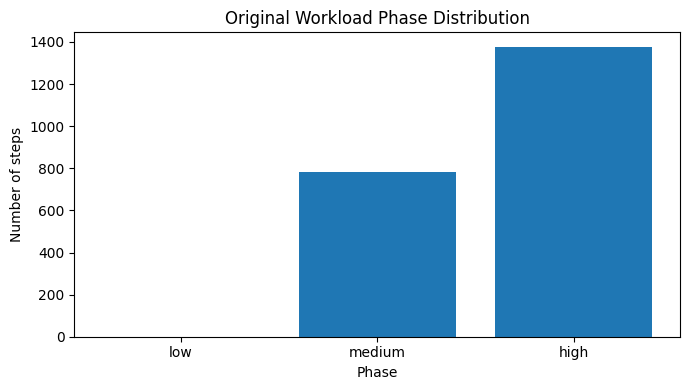

In [52]:
original_df["phase_inferred"] = pd.cut(
    original_df["demand"],
    bins=[-np.inf, 0.40, 0.75, np.inf],
    labels=["low", "medium", "high"]
)

phase_counts = (
    original_df["phase_inferred"]
    .value_counts()
    .reindex(["low", "medium", "high"])
    .fillna(0)
    .astype(int)
    .reset_index()
)

phase_counts.columns = ["phase", "count"]
phase_counts["rate"] = phase_counts["count"] / max(len(original_df), 1)

display(phase_counts)

phase_counts.to_csv(OUT_DIR / "original_phase_distribution.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(phase_counts["phase"], phase_counts["count"])
plt.title("Original Workload Phase Distribution")
plt.xlabel("Phase")
plt.ylabel("Number of steps")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_original_phase_distribution.png", dpi=200)
plt.show()

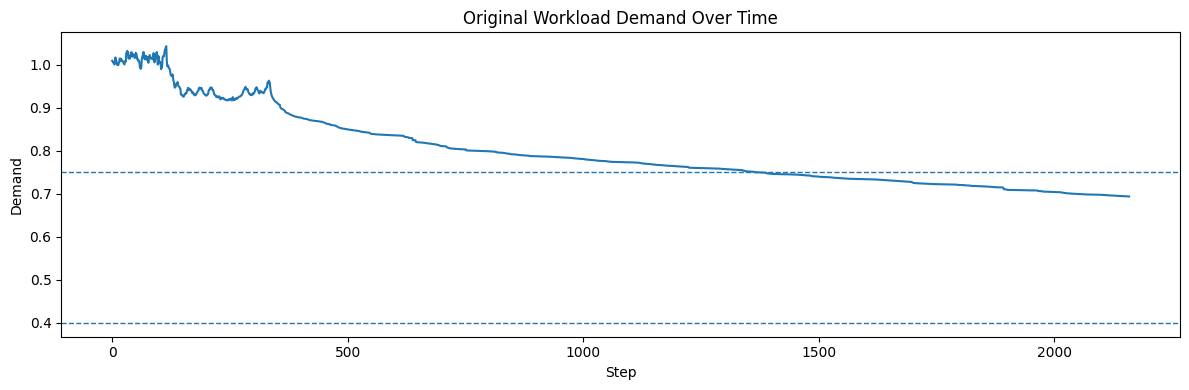

In [53]:
plt.figure(figsize=(12, 4))
plt.plot(original_df.index, original_df["demand"])
plt.axhline(0.40, linestyle="--", linewidth=1)
plt.axhline(0.75, linestyle="--", linewidth=1)
plt.title("Original Workload Demand Over Time")
plt.xlabel("Step")
plt.ylabel("Demand")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_original_demand_over_time.png", dpi=200)
plt.show()

## 4. Tạo environment evaluation

Fix lỗi workload 2160 dòng nhưng environment cần `episode_length + 1` điểm:

```python
EVAL_EPISODE_LENGTH = len(original_workload) - 1
```

Notebook này chạy original workload từ đầu tới gần cuối, không random phase reset.

In [54]:
original_workload = load_workload_csv(str(ORIGINAL_WORKLOAD_PATH))

def safe_replace_config(cfg, **kwargs):
    """
    Replace EnvConfig an toàn: chỉ thay những field tồn tại trong EnvConfig.
    """
    if not is_dataclass(cfg):
        return cfg

    valid_fields = {f.name for f in fields(cfg)}
    filtered = {k: v for k, v in kwargs.items() if k in valid_fields}
    return replace(cfg, **filtered)


base_config = EnvConfig()

# Environment cần current step + next step.
# Nếu original workload có 2160 dòng thì episode_length nên là 2159.
EVAL_EPISODE_LENGTH = int(len(original_workload)) - 1

config_kwargs = {
    "seed": SEEDS[0],
    "episode_length": EVAL_EPISODE_LENGTH,
    "balanced_phase_reset": False,
}

if VM_SNAPSHOT_PATH.exists():
    config_kwargs["vm_snapshot_path"] = str(VM_SNAPSHOT_PATH)
    print("Using VM snapshots:", VM_SNAPSHOT_PATH)
else:
    print("VM snapshots not found. Evaluation will use fallback VM grouping.")

eval_config = safe_replace_config(base_config, **config_kwargs)

print("Original workload length:", len(original_workload))
print("Eval episode_length:", eval_config.episode_length)
print("Eval balanced_phase_reset:", eval_config.balanced_phase_reset)

if hasattr(eval_config, "vm_snapshot_path"):
    print("Eval vm_snapshot_path:", eval_config.vm_snapshot_path)

Using VM snapshots: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\vm_snapshots.csv
Original workload length: 2160
Eval episode_length: 2159
Eval balanced_phase_reset: False
Eval vm_snapshot_path: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\vm_snapshots.csv


## 5. Evaluate 3 PPO agents và baselines trên original workload

Phần này:
- Load lần lượt model seed42, seed66, seed123.
- Chạy từng agent trên original workload.
- Chạy baseline một lần trên cùng original workload.
- Lưu trace và metrics.

In [55]:
def make_env(seed: int):
    cfg = safe_replace_config(
        eval_config,
        seed=seed,
        episode_length=EVAL_EPISODE_LENGTH,
        balanced_phase_reset=False,
    )
    return CloudEnergyEnv(workload=original_workload, config=cfg)


def evaluate_and_save(policy_name: str, policy, seed: int):
    """
    Chạy 1 policy trên original workload, lưu metrics, trace CSV và figures.
    """
    env = make_env(seed=seed)

    metrics = run_policy(env, policy)
    metrics_dict = asdict(metrics)
    metrics_dict["policy"] = policy_name
    metrics_dict["seed"] = seed

    trace_df = trace_to_dataframe(env.trace)
    trace_df["policy"] = policy_name
    trace_df["seed"] = seed

    if "action_name" in trace_df.columns and len(trace_df) > 0:
        metrics_dict["keep_rate"] = float((trace_df["action_name"] == "KEEP").mean())
        metrics_dict["distinct_actions"] = int(trace_df["action_name"].nunique())
    else:
        metrics_dict["keep_rate"] = np.nan
        metrics_dict["distinct_actions"] = np.nan

    prefix = policy_name.replace(" ", "_").replace("/", "_")
    policy_out_dir = OUT_DIR / prefix
    policy_out_dir.mkdir(parents=True, exist_ok=True)

    trace_path = policy_out_dir / f"{prefix}_trace.csv"
    trace_df.to_csv(trace_path, index=False)

    save_trace_artifacts(env.trace, policy_out_dir, prefix=prefix)

    return metrics_dict, trace_df


all_metrics = []
all_traces = []

# 1) Evaluate 3 PPO agents đã train từ multiphase
for seed in SEEDS:
    print("=" * 90)
    print(f"Evaluating PPO seed{seed} trained on multiphase, tested on original workload")
    print("=" * 90)

    model_path = MODEL_PATHS[seed]
    model = MaskablePPO.load(str(model_path), device="cpu")

    policy_name = f"PPO_seed{seed}_trained_multiphase"

    metrics_dict, trace_df = evaluate_and_save(
        policy_name=policy_name,
        policy=model,
        seed=seed,
    )

    metrics_dict["model_path"] = str(model_path)

    all_metrics.append(metrics_dict)
    all_traces.append(trace_df)


# 2) Evaluate baselines một lần trên original workload
# Do EVAL_EPISODE_LENGTH = len(workload)-1 nên start index cố định là 0.
baseline_policies = {
    "RoundRobin": RoundRobinPolicy(),
    "Threshold": ThresholdPolicy(),
    "BestFit": BestFitPolicy(),
    "FixedKeep": FixedPolicy(action=0),
}

BASELINE_SEED = SEEDS[0]

for policy_name, policy in baseline_policies.items():
    print("=" * 90)
    print(f"Evaluating baseline {policy_name} on original workload")
    print("=" * 90)

    metrics_dict, trace_df = evaluate_and_save(
        policy_name=policy_name,
        policy=policy,
        seed=BASELINE_SEED,
    )

    metrics_dict["base_policy"] = policy_name

    all_metrics.append(metrics_dict)
    all_traces.append(trace_df)


summary_df = pd.DataFrame(all_metrics)
all_trace_df = pd.concat(all_traces, ignore_index=True)

summary_path = OUT_DIR / "evaluation_results_original_three_seeds.csv"
trace_path = OUT_DIR / "all_policy_traces_original_three_seeds.csv"

summary_df.to_csv(summary_path, index=False)
all_trace_df.to_csv(trace_path, index=False)

print("Saved summary:", summary_path)
print("Saved all traces:", trace_path)

display(summary_df)

Evaluating PPO seed66 trained on multiphase, tested on original workload
Evaluating baseline RoundRobin on original workload
Evaluating baseline Threshold on original workload
Evaluating baseline BestFit on original workload
Evaluating baseline FixedKeep on original workload
Saved summary: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds\evaluation_results_original_three_seeds.csv
Saved all traces: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds\all_policy_traces_original_three_seeds.csv


,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations,total_migration_cost,policy,seed,keep_rate,distinct_actions,model_path,base_policy
0,-6987.849161,3.408327e+06,2.392384e+06,1578.660081,1.424039,0.000274,8.0,0.0,0.0,60.588640,1,680,59.769047,PPO_seed66_trained_multiphase,66,0.996295,4,C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-E...,NaN
1,-9032.613917,3.943537e+06,2.829591e+06,1826.557110,1.392675,0.000000,8.0,0.0,0.0,57.934953,1,239,28.007663,RoundRobin,66,0.999537,2,NaN,RoundRobin
2,-9032.613917,3.943537e+06,2.829591e+06,1826.557110,1.392675,0.000000,8.0,0.0,0.0,57.934953,1,239,28.007663,Threshold,66,0.999537,2,NaN,Threshold
3,-9032.613917,3.943537e+06,2.829591e+06,1826.557110,1.392675,0.000000,8.0,0.0,0.0,57.934953,1,239,28.007663,BestFit,66,0.999537,2,NaN,BestFit
4,-8076.838639,3.803593e+06,2.677160e+06,1761.738198,1.419586,0.000793,7.0,1.0,0.0,56.792332,0,3533,105.400112,FixedKeep,66,1.000000,1,NaN,FixedKeep


## 6. Tính energy saving của từng PPO seed so với baselines

In [56]:
ppo_summary_df = summary_df[summary_df["policy"].str.startswith("PPO_")].copy()
baseline_summary_df = summary_df[~summary_df["policy"].str.startswith("PPO_")].copy()

saving_rows = []

for _, ppo_row in ppo_summary_df.iterrows():
    ppo_policy = ppo_row["policy"]
    ppo_energy = float(ppo_row["total_energy"])

    for _, base_row in baseline_summary_df.iterrows():
        baseline_name = base_row["policy"]
        baseline_energy = float(base_row["total_energy"])

        saving_percent = (
            (baseline_energy - ppo_energy) / baseline_energy * 100
            if baseline_energy > 0
            else np.nan
        )

        saving_rows.append({
            "ppo_policy": ppo_policy,
            "baseline": baseline_name,
            "ppo_total_energy": ppo_energy,
            "baseline_total_energy": baseline_energy,
            "energy_saving_percent": saving_percent,
        })

saving_df = pd.DataFrame(saving_rows)

saving_path = OUT_DIR / "energy_saving_vs_baselines_original_three_seeds.csv"
saving_df.to_csv(saving_path, index=False)

display(saving_df)
print("Saved:", saving_path)

,ppo_policy,baseline,ppo_total_energy,baseline_total_energy,energy_saving_percent
0,PPO_seed66_trained_multiphase,RoundRobin,3.408327e+06,3.943537e+06,13.571819
1,PPO_seed66_trained_multiphase,Threshold,3.408327e+06,3.943537e+06,13.571819
2,PPO_seed66_trained_multiphase,BestFit,3.408327e+06,3.943537e+06,13.571819
3,PPO_seed66_trained_multiphase,FixedKeep,3.408327e+06,3.803593e+06,10.391903


Saved: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds\energy_saving_vs_baselines_original_three_seeds.csv


## 7. Xếp hạng 3 PPO seed theo trade-off tổng thể

Không chọn seed chỉ vì energy thấp nhất.  
Seed đại diện được chọn theo trade-off giữa:
- total energy
- SLA violation
- migration
- temperature
- PUE

In [57]:
ppo_rank_df = ppo_summary_df.copy()

rank_cols = []

if "total_energy" in ppo_rank_df.columns:
    ppo_rank_df["rank_energy"] = ppo_rank_df["total_energy"].rank(ascending=True)
    rank_cols.append("rank_energy")

if "sla_rate" in ppo_rank_df.columns:
    ppo_rank_df["rank_sla"] = ppo_rank_df["sla_rate"].rank(ascending=True)
    rank_cols.append("rank_sla")

if "total_migrations" in ppo_rank_df.columns:
    ppo_rank_df["rank_migration"] = ppo_rank_df["total_migrations"].rank(ascending=True)
    rank_cols.append("rank_migration")

if "avg_temp" in ppo_rank_df.columns:
    ppo_rank_df["rank_temp"] = ppo_rank_df["avg_temp"].rank(ascending=True)
    rank_cols.append("rank_temp")

if "avg_pue" in ppo_rank_df.columns:
    ppo_rank_df["rank_pue"] = ppo_rank_df["avg_pue"].rank(ascending=True)
    rank_cols.append("rank_pue")

ppo_rank_df["overall_rank_score"] = ppo_rank_df[rank_cols].mean(axis=1)
ppo_rank_df = ppo_rank_df.sort_values("overall_rank_score").reset_index(drop=True)

rank_path = OUT_DIR / "ppo_seed_ranking_original.csv"
ppo_rank_df.to_csv(rank_path, index=False)

display(ppo_rank_df)

BEST_PPO_POLICY = ppo_rank_df.iloc[0]["policy"]
BEST_PPO_SEED = int(ppo_rank_df.iloc[0]["seed"])

print("Best representative PPO seed on original workload:")
print("Policy:", BEST_PPO_POLICY)
print("Seed:", BEST_PPO_SEED)
print("Rank score:", ppo_rank_df.iloc[0]["overall_rank_score"])
print("Saved:", rank_path)

,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations,total_migration_cost,policy,seed,keep_rate,distinct_actions,model_path,base_policy,rank_energy,rank_sla,rank_migration,rank_temp,rank_pue,overall_rank_score
0,-6987.849161,3.408327e+06,2.392384e+06,1578.660081,1.424039,0.000274,8.0,0.0,0.0,60.58864,1,680,59.769047,PPO_seed66_trained_multiphase,66,0.996295,4,C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-E...,NaN,1.0,1.0,1.0,1.0,1.0,1.0


Best representative PPO seed on original workload:
Policy: PPO_seed66_trained_multiphase
Seed: 66
Rank score: 1.0
Saved: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds\ppo_seed_ranking_original.csv


## 8. Vẽ biểu đồ so sánh chính

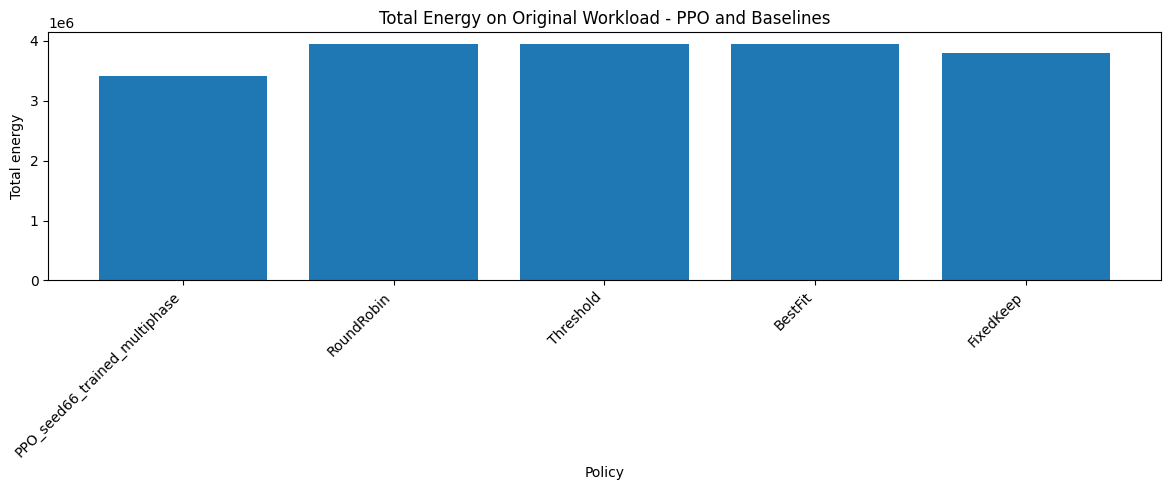

In [58]:
plt.figure(figsize=(12, 5))
plt.bar(summary_df["policy"], summary_df["total_energy"])
plt.title("Total Energy on Original Workload - PPO and Baselines")
plt.xlabel("Policy")
plt.ylabel("Total energy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_total_energy_comparison_original_three_seeds.png", dpi=200)
plt.show()

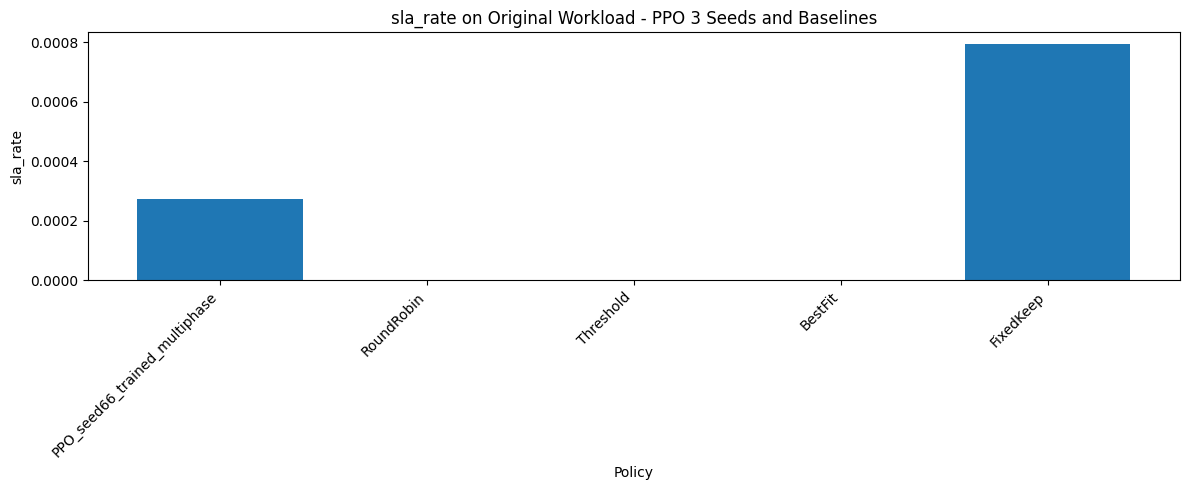

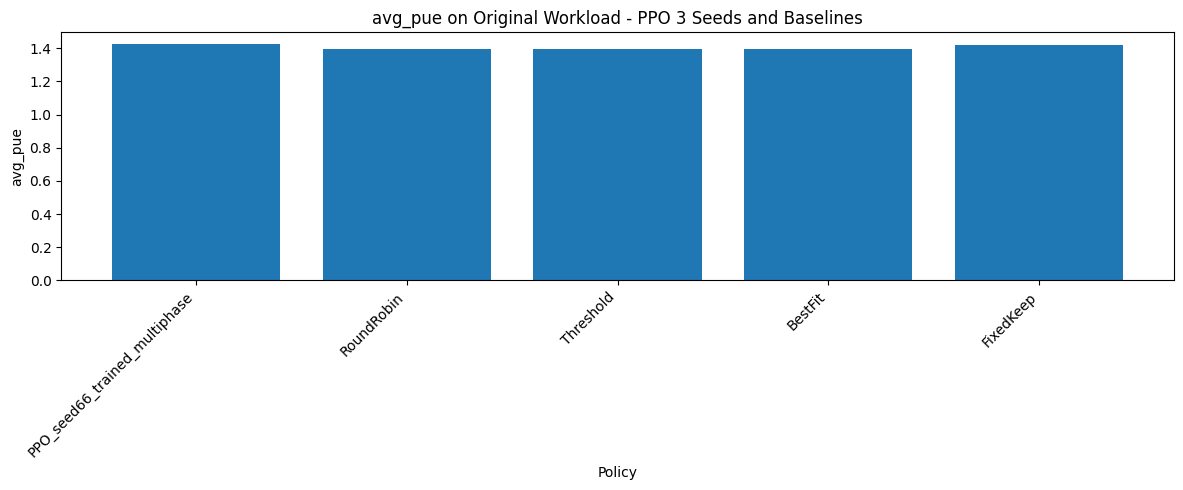

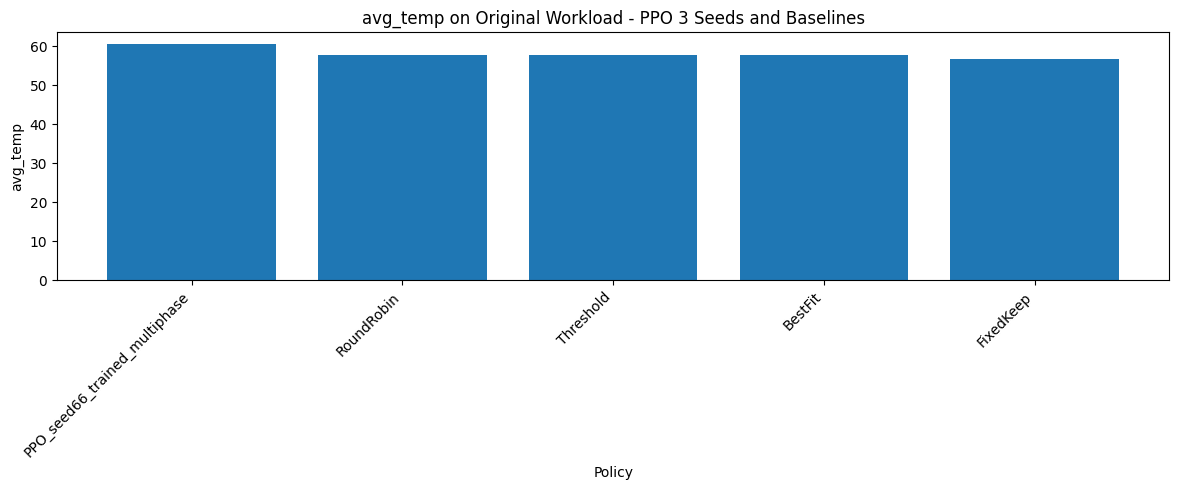

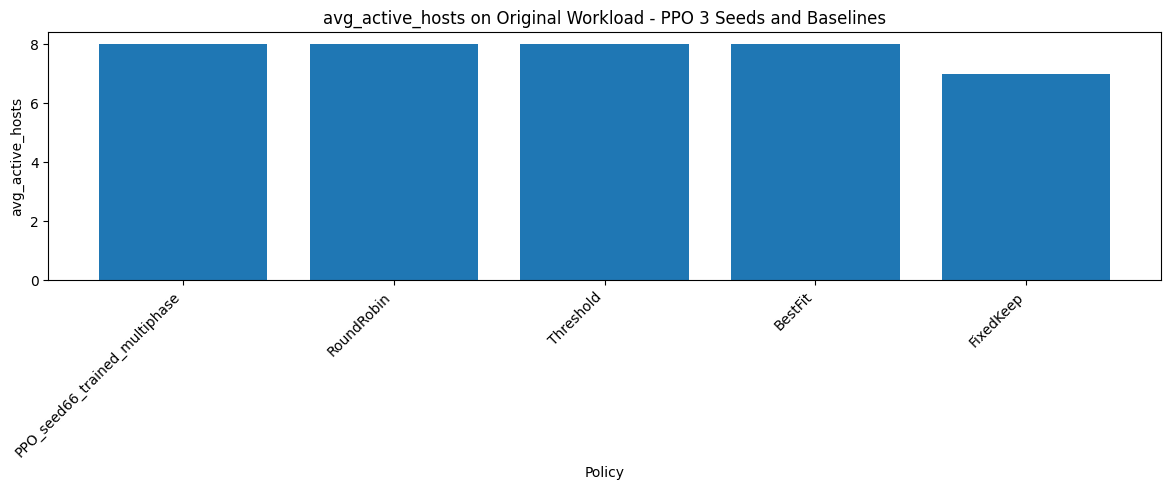

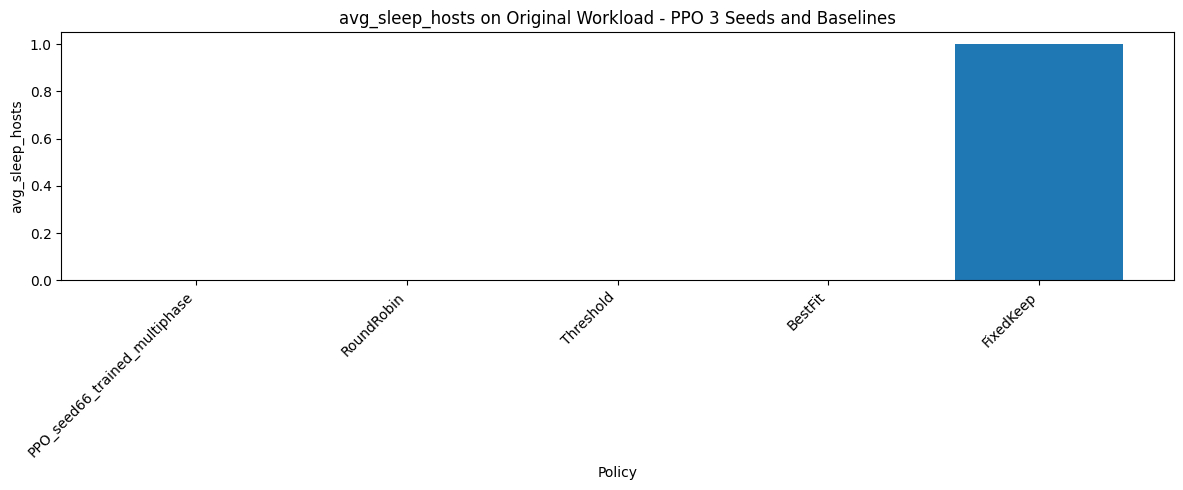

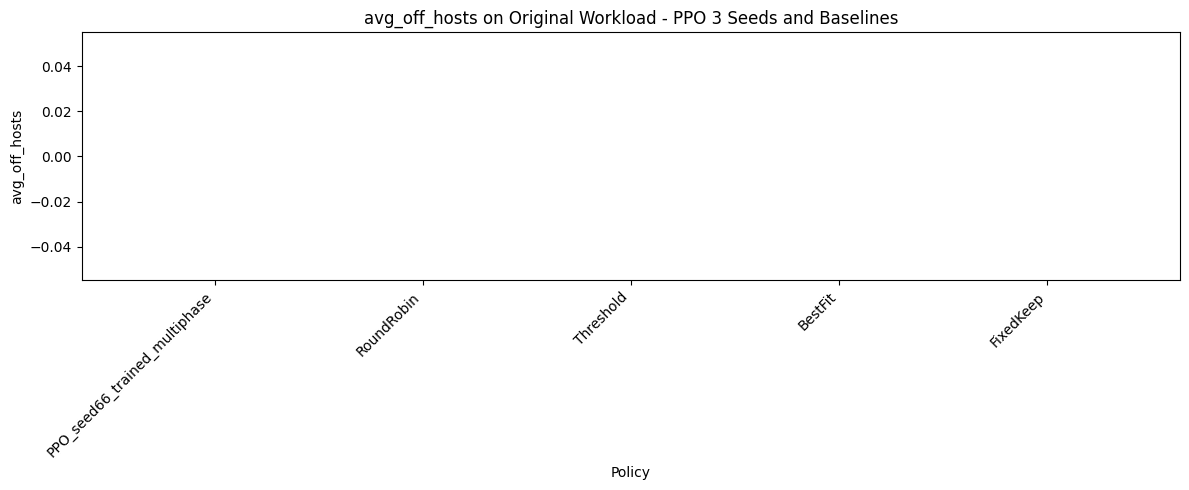

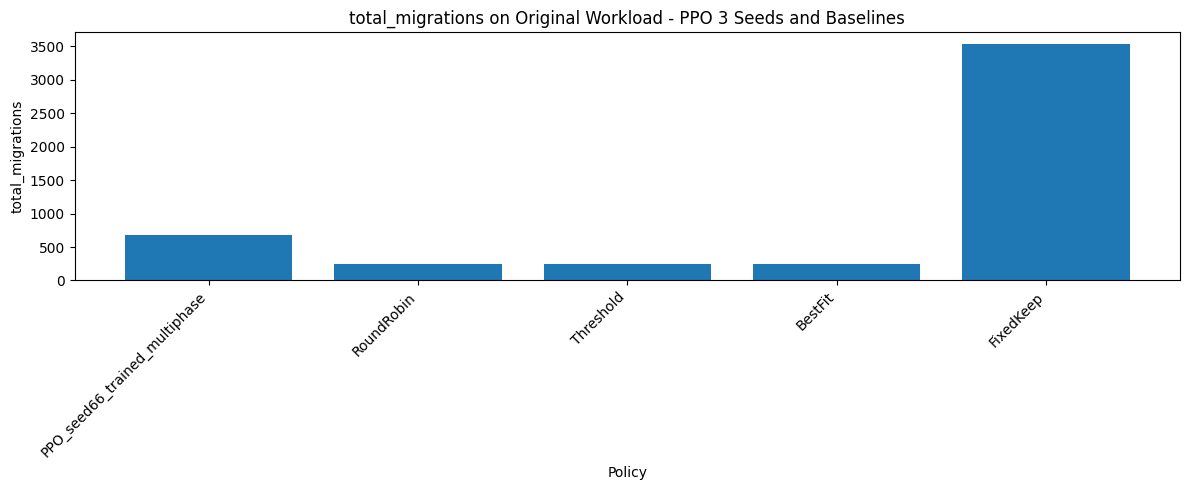

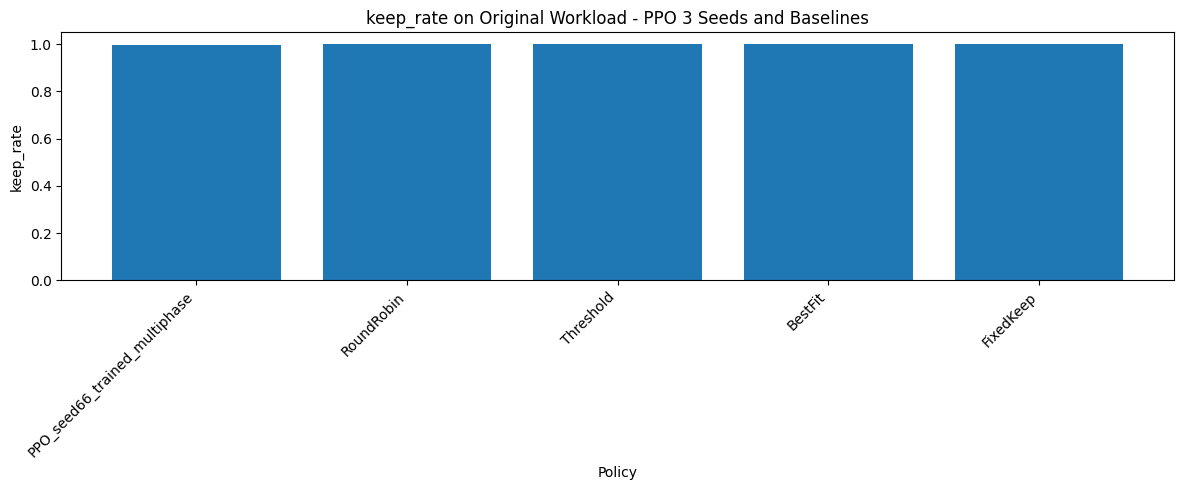

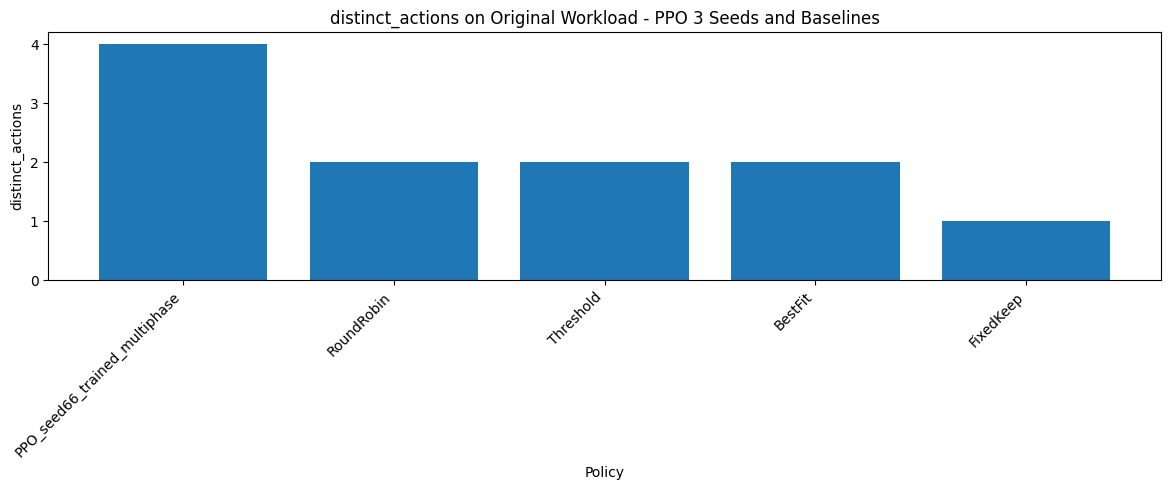

In [59]:
metric_cols = [
    "sla_rate",
    "avg_pue",
    "avg_temp",
    "avg_active_hosts",
    "avg_sleep_hosts",
    "avg_off_hosts",
    "total_migrations",
    "keep_rate",
    "distinct_actions",
]

for col in metric_cols:
    if col not in summary_df.columns:
        continue

    plt.figure(figsize=(12, 5))
    plt.bar(summary_df["policy"], summary_df[col])
    plt.title(f"{col} on Original Workload - PPO 3 Seeds and Baselines")
    plt.xlabel("Policy")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"04_{col}_comparison_original_three_seeds.png", dpi=200)
    plt.show()

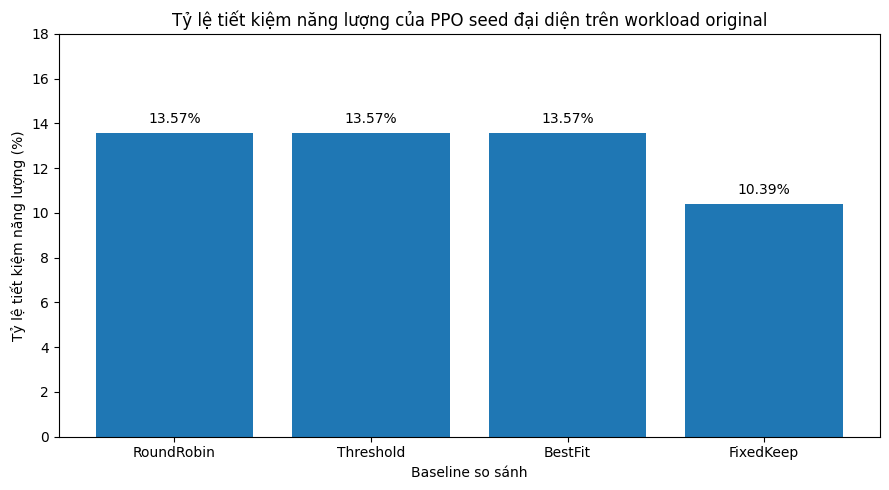

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# Dữ liệu từ bảng của bạn
df = pd.DataFrame({
    "baseline": ["RoundRobin", "Threshold", "BestFit", "FixedKeep"],
    "energy_saving_percent": [13.571819, 13.571819, 13.571819, 10.391903]
})

plt.figure(figsize=(9, 5))
bars = plt.bar(df["baseline"], df["energy_saving_percent"])

plt.title("Tỷ lệ tiết kiệm năng lượng của PPO seed đại diện trên workload original")
plt.xlabel("Baseline so sánh")
plt.ylabel("Tỷ lệ tiết kiệm năng lượng (%)")

# Nếu muốn có mốc tham chiếu 15% thì giữ 2 dòng này
# plt.axhline(y=15, linestyle="--", linewidth=1, label="Mốc tham chiếu 15%")
# plt.legend()

# Hiển thị số % trên đầu cột
for bar, value in zip(bars, df["energy_saving_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 18)
plt.tight_layout()
plt.show()

## 9. Action distribution và behavior của seed đại diện

,action_name,count,rate
0,KEEP,2151,0.996295
1,DVFS_DOWN,4,0.001853
2,DVFS_UP,3,0.001390
3,WAKE_ONE,1,0.000463


Saved: C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\original_eval_from_trained_model\three_seeds\best_ppo_action_distribution_original_seed66.csv


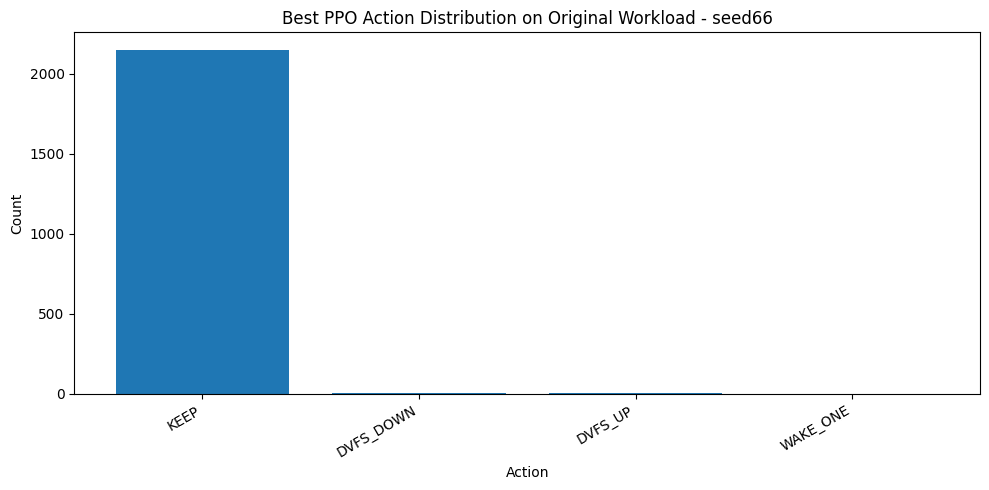

In [61]:
best_ppo_trace = all_trace_df[all_trace_df["policy"] == BEST_PPO_POLICY].copy()

action_counts = (
    best_ppo_trace["action_name"]
    .value_counts()
    .rename_axis("action_name")
    .reset_index(name="count")
)

action_counts["rate"] = action_counts["count"] / max(action_counts["count"].sum(), 1)

action_path = OUT_DIR / f"best_ppo_action_distribution_original_seed{BEST_PPO_SEED}.csv"
action_counts.to_csv(action_path, index=False)

display(action_counts)
print("Saved:", action_path)

plt.figure(figsize=(10, 5))
plt.bar(action_counts["action_name"], action_counts["count"])
plt.title(f"Best PPO Action Distribution on Original Workload - seed{BEST_PPO_SEED}")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / f"05_best_ppo_action_distribution_original_seed{BEST_PPO_SEED}.png", dpi=200)
plt.show()

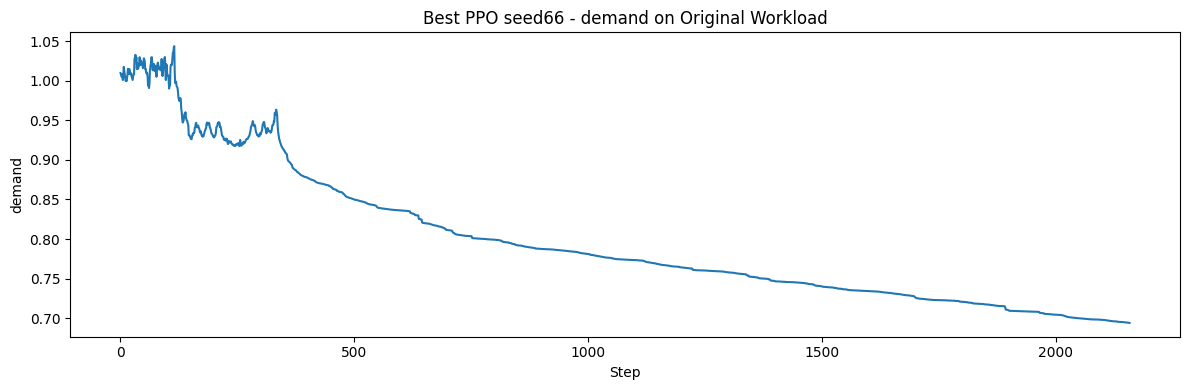

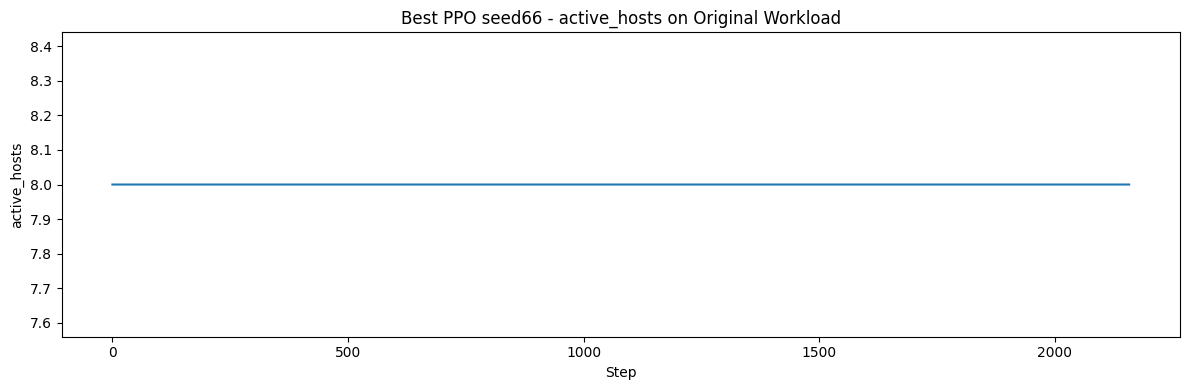

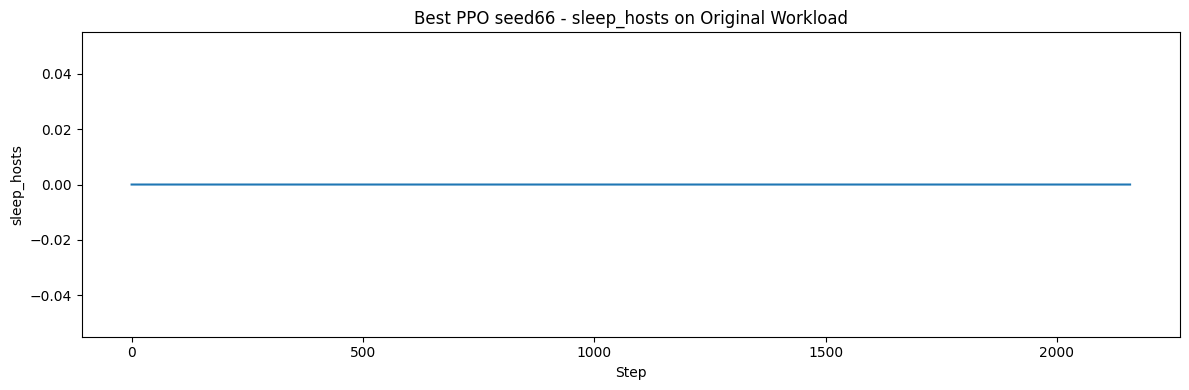

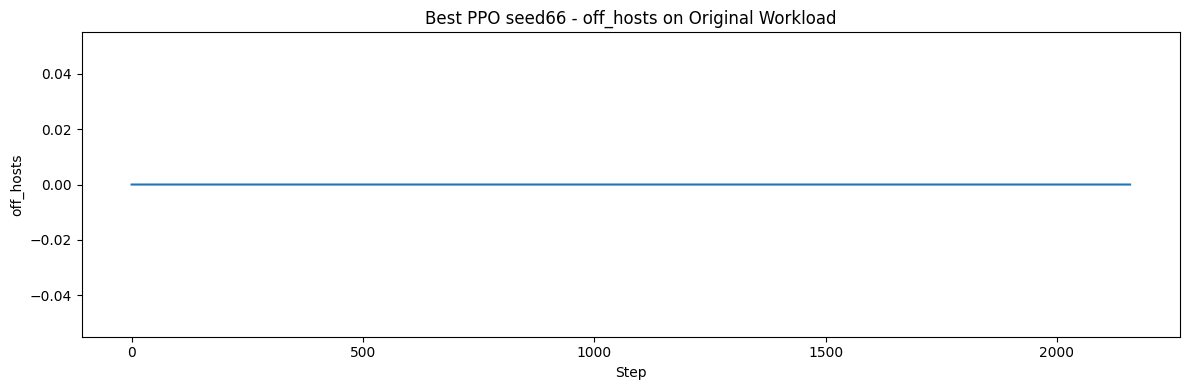

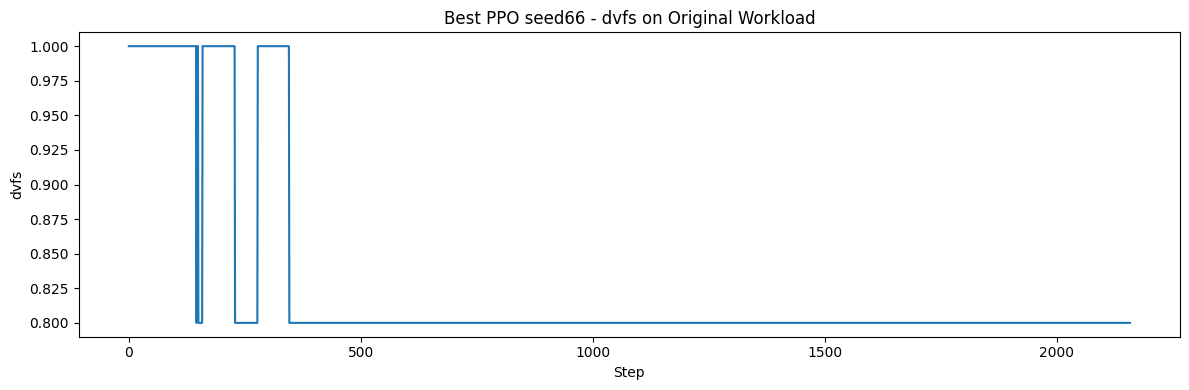

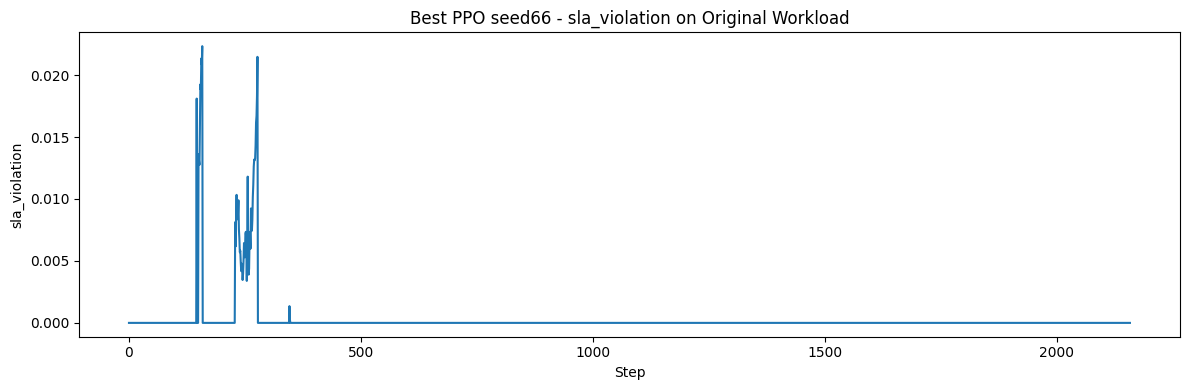

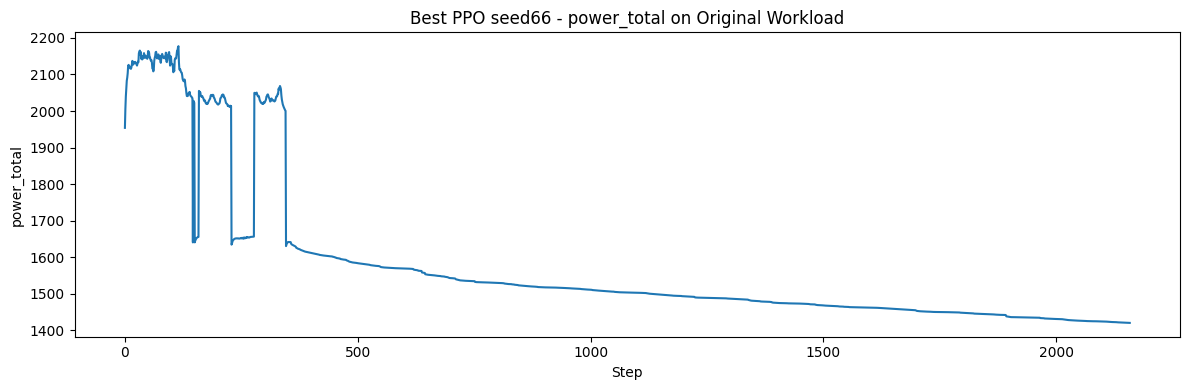

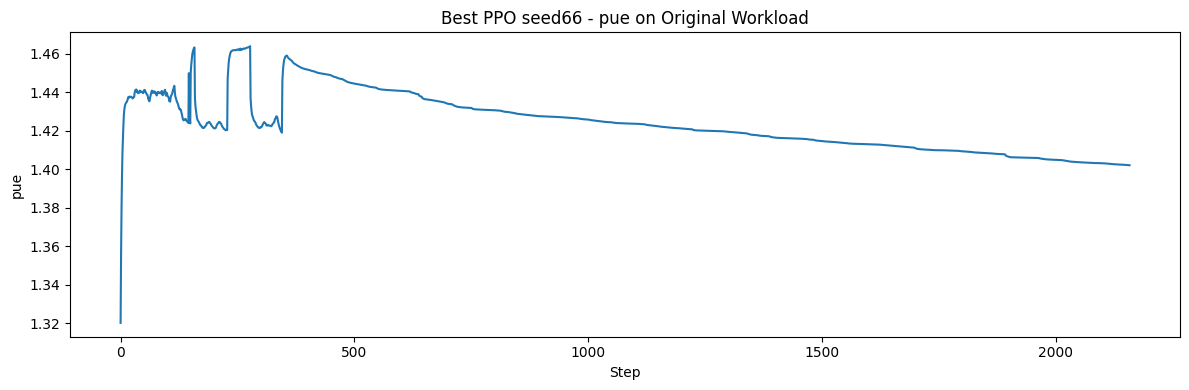

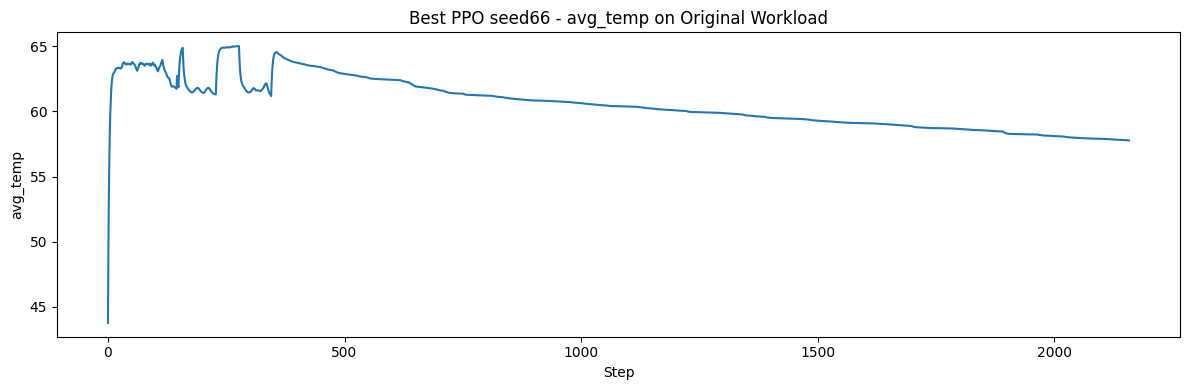

In [62]:
plot_cols = [
    "demand",
    "active_hosts",
    "sleep_hosts",
    "off_hosts",
    "dvfs",
    "sla_violation",
    "power_total",
    "pue",
    "avg_temp",
]

for col in plot_cols:
    if col not in best_ppo_trace.columns:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(best_ppo_trace["step"], best_ppo_trace[col])
    plt.title(f"Best PPO seed{BEST_PPO_SEED} - {col} on Original Workload")
    plt.xlabel("Step")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"06_best_ppo_seed{BEST_PPO_SEED}_{col}_over_time_original.png", dpi=200)
    plt.show()

## 10. Auto-generate nhận xét ngắn cho báo cáo

In [63]:
def fmt_pct(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:.2f}%"

def fmt_num(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:,.3f}"

print("=" * 90)
print("NHẬN XÉT GỢI Ý CHO BÁO CÁO")
print("=" * 90)

low_count = int(phase_counts.loc[phase_counts["phase"] == "low", "count"].iloc[0])
medium_count = int(phase_counts.loc[phase_counts["phase"] == "medium", "count"].iloc[0])
high_count = int(phase_counts.loc[phase_counts["phase"] == "high", "count"].iloc[0])

print(f"- Original workload có low={low_count}, medium={medium_count}, high={high_count} steps.")
print("- Notebook 03 không train lại PPO.")
print("- Notebook 03 load 3 agent PPO đã train trên multiphase: seed42, seed66, seed123.")
print("- Sau đó evaluate 3 agent này trên original workload để kiểm tra generalization.")

print()
print("Energy saving của từng PPO seed so với baseline:")
display(saving_df)

print()
print("Xếp hạng 3 PPO seed theo trade-off energy/SLA/migration/temp/PUE:")
display(ppo_rank_df)

best_row = ppo_rank_df.iloc[0]

print()
print(f"Seed đại diện tốt nhất trên original workload: seed{BEST_PPO_SEED}")
print(f"- Policy: {BEST_PPO_POLICY}")
print(f"- Total energy: {fmt_num(best_row.get('total_energy', np.nan))}")
print(f"- SLA rate: {fmt_num(best_row.get('sla_rate', np.nan))}")
print(f"- Avg PUE: {fmt_num(best_row.get('avg_pue', np.nan))}")
print(f"- Avg temp: {fmt_num(best_row.get('avg_temp', np.nan))}")
print(f"- Avg active hosts: {fmt_num(best_row.get('avg_active_hosts', np.nan))}")
print(f"- Avg off hosts: {fmt_num(best_row.get('avg_off_hosts', np.nan))}")
print(f"- Total migrations: {fmt_num(best_row.get('total_migrations', np.nan))}")

report_text = (
    "Sau khi huấn luyện PPO trên workload multiphase ở Notebook 02, nhóm tiếp tục đánh giá bổ sung trên original workload. "
    "Notebook 03 không train lại mô hình, mà lần lượt load ba agent PPO đã train tương ứng với seed42, seed66 và seed123. "
    "Mục tiêu của bước này là kiểm tra khả năng generalization của agent khi chuyển từ workload multiphase sang original workload. "
    "Kết quả được so sánh theo total energy, SLA violation, migration, PUE và temperature. "
    "Seed có trade-off tốt nhất được chọn làm representative seed để phân tích chi tiết. "
    "Do original workload có rất ít hoặc không có pha tải thấp rõ rệt, hành vi Sleep/Off có thể không mạnh như trong multiphase workload; "
    "trong trường hợp này, mức tiết kiệm năng lượng chủ yếu đến từ điều chỉnh DVFS."
)

print()
print("Đoạn viết gợi ý:")
print(report_text)

NHẬN XÉT GỢI Ý CHO BÁO CÁO
- Original workload có low=0, medium=783, high=1377 steps.
- Notebook 03 không train lại PPO.
- Notebook 03 load 3 agent PPO đã train trên multiphase: seed42, seed66, seed123.
- Sau đó evaluate 3 agent này trên original workload để kiểm tra generalization.

Energy saving của từng PPO seed so với baseline:


,ppo_policy,baseline,ppo_total_energy,baseline_total_energy,energy_saving_percent
0,PPO_seed66_trained_multiphase,RoundRobin,3.408327e+06,3.943537e+06,13.571819
1,PPO_seed66_trained_multiphase,Threshold,3.408327e+06,3.943537e+06,13.571819
2,PPO_seed66_trained_multiphase,BestFit,3.408327e+06,3.943537e+06,13.571819
3,PPO_seed66_trained_multiphase,FixedKeep,3.408327e+06,3.803593e+06,10.391903



Xếp hạng 3 PPO seed theo trade-off energy/SLA/migration/temp/PUE:


,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_temp,total_switches,total_migrations,total_migration_cost,policy,seed,keep_rate,distinct_actions,model_path,base_policy,rank_energy,rank_sla,rank_migration,rank_temp,rank_pue,overall_rank_score
0,-6987.849161,3.408327e+06,2.392384e+06,1578.660081,1.424039,0.000274,8.0,0.0,0.0,60.58864,1,680,59.769047,PPO_seed66_trained_multiphase,66,0.996295,4,C:\Users\PHUONG NGHI\Documents\NT549.Q21-DRL-E...,NaN,1.0,1.0,1.0,1.0,1.0,1.0



Seed đại diện tốt nhất trên original workload: seed66
- Policy: PPO_seed66_trained_multiphase
- Total energy: 3,408,327.115
- SLA rate: 0.000
- Avg PUE: 1.424
- Avg temp: 60.589
- Avg active hosts: 8.000
- Avg off hosts: 0.000
- Total migrations: 680.000

Đoạn viết gợi ý:
Sau khi huấn luyện PPO trên workload multiphase ở Notebook 02, nhóm tiếp tục đánh giá bổ sung trên original workload. Notebook 03 không train lại mô hình, mà lần lượt load ba agent PPO đã train tương ứng với seed42, seed66 và seed123. Mục tiêu của bước này là kiểm tra khả năng generalization của agent khi chuyển từ workload multiphase sang original workload. Kết quả được so sánh theo total energy, SLA violation, migration, PUE và temperature. Seed có trade-off tốt nhất được chọn làm representative seed để phân tích chi tiết. Do original workload có rất ít hoặc không có pha tải thấp rõ rệt, hành vi Sleep/Off có thể không mạnh như trong multiphase workload; trong trường hợp này, mức tiết kiệm năng lượng chủ yếu đến từ 

## 11. Kết luận của Notebook 03

Notebook 03 trả lời câu hỏi:

> Agent được train trên workload multiphase thì khi đem qua original workload có hoạt động ổn không?

Cách trình bày đúng:
- Notebook 02 là thí nghiệm chính: train + evaluate trên multiphase workload.
- Notebook 03 là thí nghiệm bổ sung: load 3 trained agents từ Notebook 02 và evaluate trên original workload.
- Notebook 03 không cập nhật trọng số model, không train lại PPO.
- Việc chọn seed đại diện dựa trên trade-off tổng thể, không chỉ dựa vào energy saving.
- Nếu original workload thiếu low phase, Sleep/Off ít xuất hiện là hợp lý, không phải lỗi.